In [1]:
import os
import time
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pathlib as pl
import shutil
import sys
import pandas as pd
import geopandas as gpd
import contextily as cx
import flopy
from modflowapi import ModflowApi
from modflowapi.extensions import ApiSimulation
import itertools
from bmi.wrapper import BMIWrapper

import pyswmm
from pyswmm import Simulation, Nodes
from pyswmm import Output
import dask

c:\Users\bbayrakt\AppData\Local\miniforge3\envs\liss\lib\site-packages\bmi\__init__.py:2: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
c:\Users\bbayrakt\AppData\Local\miniforge3\envs\liss\lib\site-packages\pkg_resources\__init__.py:2832: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('pydap')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
c:\Users\bbayrakt\AppData\Local\miniforge3\envs\liss\lib\site-packages\pkg_resources\__init__.py:2832: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('pydap.responses')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/e

In [2]:
sys.path.append("../common")
from liss_settings import \
    libmf6, \
    get_dflow_grid_name, get_dflow_dtuser, \
    get_modflow_coupling_tag, get_modflow_grid_name, \
    silent, verbosity, \
    print_path, print_value

import swmm_mf_connect_1

# Load Names

dflow

In [3]:
dflow_path = pl.Path("../dflow-fm/coarse/tides/base")# change this if using a different D-Flow FM control file
dflow_grid_name = get_dflow_grid_name(dflow_path / 'FlowFM.mdu')
print(dflow_grid_name)
dflowfm_dtuser = get_dflow_dtuser(dflow_path / 'FlowFM.mdu')
print(f'{dflowfm_dtuser} seconds')

LIS_LowRES_012026_net
300.0 seconds


modflow

In [4]:
mf_grid_name = get_modflow_grid_name()
mf_grid_name

'gp_chd'

swmm

In [5]:
swmm_path = pl.Path("../swmm/gp/greenport_detailedsewer_v4_nosub175.inp").resolve()
print(swmm_path, swmm_path.is_file())

fpth = swmm_path.with_suffix(".out")
if fpth.is_file():
    print(f"removing: '{fpth}'")
    fpth.unlink()
fpth = swmm_path.with_suffix(".rpt")
if fpth.is_file():
    print(f"removing: '{fpth}'")
    fpth.unlink()

D:\LISS_GW\GitRepo_CoupledModels\nywsc_compound_flooding\swmm\gp\greenport_detailedsewer_v4_nosub175.inp True
removing: 'D:\LISS_GW\GitRepo_CoupledModels\nywsc_compound_flooding\swmm\gp\greenport_detailedsewer_v4_nosub175.rpt'


#  Unit Conversions

In [6]:
d2sec = 24. * 60. * 60.
hrs2sec = 60. * 60. 
m2ft = 3.28081
cfd2cms = 1.0 / ((m2ft**3) * 86400.)

# MODFLOW coupling frequency

Change the `mf_couple_freq_hours` value. Only tested for multiple of the D-Flow FM DtUser variable. Will not work for `mf_couple_freq_hours` values greater than 24.

In [7]:
mf_couple_freq_hours = 12 # Change this value to change the coupling frequency
mf_couple_freq = mf_couple_freq_hours * hrs2sec
dflow_per_mf = int(mf_couple_freq / dflowfm_dtuser)
print(f"MODFLOW coupling frequency {mf_couple_freq_hours} hours\nMODFLOW coupled to D-FLOW FM every {dflow_per_mf} output time step ({dflowfm_dtuser} sec.)") 

mf_tag = get_modflow_coupling_tag(mf_couple_freq_hours)
print(f"MODFLOW coupling tag: {mf_tag}")

mf_couple_nstp = int(86400.0 / (dflow_per_mf * dflowfm_dtuser))
print(f"MODFLOW time steps per day: {mf_couple_nstp }")

MODFLOW coupling frequency 12 hours
MODFLOW coupled to D-FLOW FM every 144 output time step (300.0 sec.)
MODFLOW coupling tag: 12.00H
MODFLOW time steps per day: 2


# Set a few variables for controlling coupling

In [8]:
HDRY = -1e30
DEPTH_MIN = 0.1

In [9]:
str(libmf6), libmf6.is_file()

('C:\\Users\\bbayrakt\\AppData\\Local\\miniforge3\\envs\\liss\\Scripts\\libmf6.dll',
 False)

# D-FLOW to MODFLOW weights



## GHB weights

In [10]:
fpath = f"../mapping/gp/dflow_{dflow_grid_name}_to_{mf_grid_name}_ghb.npz"
npzfile = np.load(fpath)
print(fpath)

dflow2mfghb = npzfile["dflow2mfghb"]
print(f'dflow2ghb shape: {dflow2mfghb.shape}')
ghbmask = npzfile["ghbmask"]
print(f'ghb mask shape :{ghbmask.shape}')
ghb2qext = npzfile["ghb2qext"]
print(f'ghb2qext shape: {ghb2qext.shape}')

../mapping/gp/dflow_LIS_LowRES_012026_net_to_gp_chd_ghb.npz
dflow2ghb shape: (72, 21660)
ghb mask shape :(72,)
ghb2qext shape: (21660, 72)


## CHD weights

In [11]:
fpath = f"../mapping/gp/dflow_{dflow_grid_name}_to_{mf_grid_name}_chd.npz"
print(fpath)
npzfile = np.load(fpath)

dflow2mfchd = npzfile["dflow2mfchd"]
print(f'dflow2chd shape: {dflow2mfchd.shape}')
chdmask = npzfile["chdmask"]
print(f'chd mask shape :{chdmask.shape}')
chd2qext = npzfile["chd2qext"]
print(f'chd2qext shape: {chd2qext.shape}')

../mapping/gp/dflow_LIS_LowRES_012026_net_to_gp_chd_chd.npz
dflow2chd shape: (691, 6491)
chd mask shape :(691,)
chd2qext shape: (6491, 691)


# Create Modflow Model

In [12]:
# Modflow Paths
mf_base_path = pl.Path("../modflow/gp_chd/base/").resolve()
mf_run_path = pl.Path(f"../modflow/gp_chd/run_{mf_tag}_withSWMM/").resolve()

In [13]:
sim = flopy.mf6.MFSimulation.load(sim_ws=mf_base_path, verbosity_level=verbosity())
gwf = sim.get_model()

In [14]:
sim.set_sim_path(mf_run_path)
(mf_run_path / 'outputs').mkdir(exist_ok=True)

## Change TDIS to defined time steps

In [15]:
# tdis = sim.get_package("TDIS")
# perioddata = tdis.perioddata.array

# mf_startdate = tdis.start_date_time.array
# mf_perioddata= tdis.perioddata.array
# # calculate date for each stress period
# mf_SPdates = [pd.to_datetime(mf_startdate)]
# for perlen, nstp, tsmult in mf_perioddata:
#     mf_SPdates.append(mf_SPdates[-1] + pd.Timedelta(days = perlen))
# # remove the last date because it is extra
# mf_SPdates = mf_SPdates[:-1]
# # Compute cumulative total times at the end of each stress period
# mf_totaltimes= tdis.perioddata.array['perlen'].cumsum()

# mf_tdis_df = pd.DataFrame({'Date':mf_SPdates,
#                            'SP': list(mf_perioddata),
#                            'totim': mf_totaltimes})

# mf_tdis_df

# perioddata["nstp"] = nstp
# print(perioddata)

# tdis.perioddata = perioddata
# print(perioddata)

## Write the new model files

In [16]:
sim.write_simulation(silent=silent())

## Create SWMM Well Package

<Axes: >

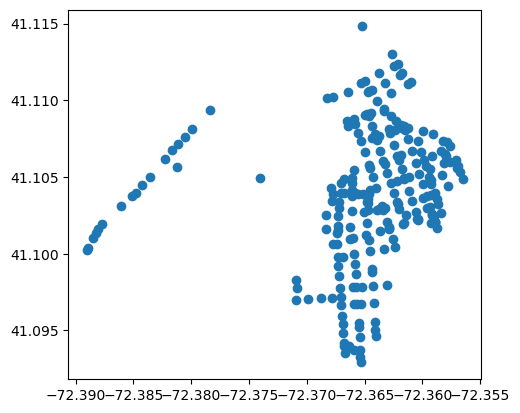

In [17]:
swmm_shp = gpd.read_file('../swmm/gp/gis/gp_invert_elevations.shp')
# Save out new shapefile to prevent issues in intersect_points_grid function 
swmm_shp_2 = swmm_shp[['Name','geometry']]
swmm_shp_path = '../swmm/gp/gis/gp_invert_elevations_2.shp'
swmm_shp_2.to_file(swmm_shp_path)
swmm_shp_2.plot()

In [18]:
import itertools
import geopandas as gpd
import pandas as pd
import pyswmm
import flopy

def intersect_points_grid(sim_ws=None, swmm_pth=None, swmm_pts_pth=None, pts_name_col='Name',  crs='epsg:4456'):
    '''
    Intersects specified points with a grid polygon and retrieves information about junctions.

    This function reads point data from a specified shapefile, samples a given number of junctions,
    and intersects these junctions with a provided grid polygon. It then retrieves the corresponding
    SWMM node information, including invert elevations, and returns the number of junctions sampled,
    a dictionary of cell IDs, a dictionary of SWMM nodes, and a dictionary of invert elevations in feet.

    Parameters:
    ----------
    sim_ws : str
        The workspace directory containing the MODFLOW 6 simulation files. If None, the function will
        attempt to load from the current working directory.
    swmm_pth : str
        The file path to the SWMM input file. 
    swmm_pts_pth : str
        The file path to the shapefile containing SWMM point data.

    crs : str, optional
        The coordinate reference system (CRS) to assign to the GeoDataFrame. Default is 'epsg:4456'.

    Returns:
    -------
    tuple
        A tuple containing:
        - junctions (list): List of selected junction names.
        - mf6_cells (dict): A dictionary mapping junction names to their corresponding cell IDs.
        - swmm_inverts (dict): A dictionary mapping junction names to their invert elevations in feet.
    '''

    print(sim_ws)
    print(swmm_pth)
    print(swmm_pts_pth)
    mf_sim = flopy.mf6.MFSimulation.load(sim_ws=sim_ws, load_only=[], verbosity_level=0)
    gwf = gwf = mf_sim.get_model(mf_sim.model_names[0])
    mg = gwf.modelgrid
    bnds = mg.geo_dataframe.set_crs(crs)
    bnds['row'] = [x[0] for x in itertools.product(range(mg.nrow), range(mg.ncol))]
    bnds['col']=  [x[1] for x in itertools.product(range(mg.nrow), range(mg.ncol))]
    bnds['idom'] = mg.idomain[0].flatten()
    bnds['top'] = mg.top.flatten()
    for i,arr in enumerate(mg.botm):
        bnds[f'bot{i+1:02d}'] = arr.flatten()
    #----------------------------------------------------------------
    junctions_shp =gpd.read_file(swmm_pts_pth)
    junctions_shp=junctions_shp.to_crs(crs)
    #junctions_shp.to_file('../swmm/PJ/PJ_Sewer_GIS/Juntions_4456.shp')

    #--------------
    # pull in the junctions listed in SWMM
    m_to_ft = 3.28084

    with pyswmm.Simulation(str(swmm_pth)) as swmm_sim:
        # some shapefile junctions might not be in SWMM? 
        junction_name = [n.nodeid for n in pyswmm.Nodes(swmm_sim)]
        junction_elev = [n.invert_elevation * m_to_ft for n in pyswmm.Nodes(swmm_sim) if n.nodeid in junction_name]
        junction_df = pd.DataFrame({pts_name_col:junction_name, 'invert_elev_ft_navd88':junction_elev})
    junction_df = junctions_shp.merge(junction_df, left_on=pts_name_col,right_on =pts_name_col)
    junction_gdf = gpd.GeoDataFrame(junction_df,geometry= junction_df['geometry'], crs = 'EPSG:4456')
    junction_df.plot()
    # print('SWMM Junctions/Nodes')
    # print(junction_gdf.columns.tolist())
    # print(bnds.columns.tolist())
    junctions_lrc = junction_gdf.sjoin(bnds.copy()).drop('index_right',axis=1)
    divs = ['top'] + [f'bot{i+1:02d}' for i in range(mg.nlay)]
    for i in range(len(divs)-1):
        ul = divs[i] # upper layer
        ll = divs[i+1] # lower layer 
        junctions_lrc.loc[(junctions_lrc.invert_elev_ft_navd88<junctions_lrc[ul]) &
                    (junctions_lrc.invert_elev_ft_navd88>junctions_lrc[ll]) &
                    (junctions_lrc['idom']>0),'lay'] = int(i)
    # missing = junctions_lrc[junctions_lrc['lay'].isna()]
    # print("Junctions without a valid layer:")
    # display(missing[['Name','invert_elev_ft_navd88','row','col','top'] + [c for c in junctions_lrc.columns if c.startswith('bot')]])
    junctions_lrc['lay'] = junctions_lrc['lay'].fillna(0).astype(int)

    print('SWMM Junctions with l,r,c')
    # slice the pts to grab desired junctions, join with model grid
    mf6_swmm_connect = junctions_lrc[['Name', 'geometry', 'invert_elev_ft_navd88', 'lay','row', 'col',]].set_index('Name')
    display(mf6_swmm_connect.head())
    mf6_swmm_connect['cid'] = [(l,r, c) for l,r,c in zip(junctions_lrc['lay'], junctions_lrc['row'], junctions_lrc['col'])]

    mf6_cells = mf6_swmm_connect['cid'].to_dict()
    # swmm_nodes = mf6_swmm_connect['swmm_node'].to_dict()
    swmm_inverts = mf6_swmm_connect['invert_elev_ft_navd88'].to_dict()
    n_junctions = len(mf6_cells)

    return n_junctions, junctions_lrc['Name'].tolist(), mf6_cells, swmm_inverts, junction_df

if __name__ == 'main':
    intersect_points_grid()


D:\LISS_GW\GitRepo_CoupledModels\nywsc_compound_flooding\modflow\gp_chd\run_12.00H_withSWMM
D:\LISS_GW\GitRepo_CoupledModels\nywsc_compound_flooding\swmm\gp\greenport_detailedsewer_v4_nosub175.inp
../swmm/gp/gis/gp_invert_elevations_2.shp
SWMM Junctions with l,r,c


,geometry,invert_elev_ft_navd88,lay,row,col
Name,,,,,
138,POINT Z (2450885.421 326236.423 0.000),42.650920,0,24,30
137,POINT Z (2450890.281 326186.424 0.000),34.776904,0,24,30
139,POINT Z (2451061.982 326070.101 0.000),39.370080,0,25,30
140,POINT Z (2451371.676 325831.337 0.000),42.650920,0,25,31
135,POINT Z (2451043.895 325678.569 0.000),39.370080,0,26,30


57 junctions
{'138': (0, 24, 30), '137': (0, 24, 30), '139': (0, 25, 30), '140': (0, 25, 31), '135': (0, 26, 30), '142': (0, 26, 30), '134': (0, 26, 30), '132': (0, 27, 30), '133': (0, 27, 30), '145': (0, 27, 31), '143': (0, 26, 31), '144': (0, 26, 31), '131': (0, 27, 30), '130': (0, 27, 30), '128': (0, 28, 30), '108': (0, 29, 30), '123': (0, 29, 30), '126': (0, 28, 30), '125': (0, 28, 31), '124': (0, 28, 31), '156': (0, 26, 31), '155': (0, 26, 32), '154': (0, 27, 32), '153': (0, 27, 32), '152': (0, 27, 32), '151': (0, 27, 32), '171': (1, 28, 31), '149': (0, 27, 31), '150': (0, 27, 32), '146': (0, 27, 31), '148': (0, 26, 31), '147': (0, 27, 31), '122': (0, 29, 31), '120': (0, 29, 31), '118': (0, 30, 31), '117': (0, 31, 31), '119': (0, 30, 31), '115': (0, 30, 31), '111': (0, 30, 30), '114': (0, 30, 30), '100': (0, 30, 29), '113': (0, 30, 29), '112': (0, 30, 29), '107': (0, 29, 29), '106': (0, 29, 29), '104': (0, 29, 28), '103': (0, 29, 29), '102': (0, 30, 29), '110': (0, 30, 30), '109':

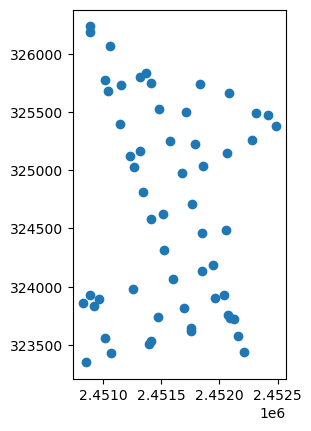

In [19]:
#from swmm_mf_connect_1 import intersect_points_grid

n_junctions, junctions, mf6_cells, swmm_inverts, possible_junctions = intersect_points_grid(sim_ws=mf_run_path , 
                                                                                            swmm_pth=str(swmm_path), 
                                                                                            swmm_pts_pth=swmm_shp_path,
                                                                                              pts_name_col='Name', crs='epsg:4456')

print(f'{n_junctions} junctions')
print(mf6_cells)
print(swmm_inverts)

In [20]:
swmm_well_sp  = []
swmm_well_obs = []
for key, value in mf6_cells.items():
    # print(key)
    # print(value)
    l = value[0]
    r = value[1]
    c = value[2]
    cell = [l,r,c,0]
    swmm_well_sp.append(cell)
    obs = (key, 'WEL', (l,r,c))
    swmm_well_obs.append(obs)

In [21]:
wel = flopy.mf6.ModflowGwfwel(
    gwf,
    save_flows=True,
    boundnames=True,
    stress_period_data={0:swmm_well_sp},
    observations= {'outputs/swmm_well_obs.csv': swmm_well_obs},
    pname='SWMM')

# Define base GHB variables

In [22]:
ghb_data0 = gwf.ghb.stress_period_data.get_dataframe()[0]
assert ghb_data0.shape[0] == ghbmask.shape[0]

# Define base CHD variables

2 CHD packages
1. Surface CHDs (chds in bay, and perimeter chd's in bay ,ALL in the top layer) which only has one external file
2. Perimeter CHDs (perimeter chds not in the bay, at all layers), 366 external files for every day. 

In [23]:
chd_all = gwf.get_package("chd_surface")
chd_data0 = chd_all.stress_period_data.get_dataframe()[0]
chd_data0.shape
chdmask.shape

# print_value(chd_data0)
assert chd_data0.shape[0] == chdmask.shape[0]
chd_all.stress_period_data.get_dataframe()[0]

,cellid_layer,cellid_row,cellid_column,head,salinity,boundname
0,0,1,45,0.234,35.000,perimeter
1,0,2,47,0.234,35.000,perimeter
2,0,3,51,0.234,35.000,perimeter
3,0,4,52,0.234,35.000,perimeter
4,0,5,53,0.234,35.000,perimeter
...,...,...,...,...,...,...
686,0,46,17,0.234,27.119,coastal
687,0,46,18,0.234,27.119,coastal
688,0,46,19,0.234,27.119,coastal
689,0,46,20,0.234,27.119,coastal


# Setup and initialize D-FLOW FM
You will need to set `dflow_dirpath` to the correct directory on your machine.

## Paths

In [24]:
dflow_dirpath = pl.Path(r"..\dflow-fm\dflowfm_dll").resolve()
dflow_base = pl.Path(r"..\dflow-fm\coarse\tides\base").resolve()
dflow_working = pl.Path(r"..\dflow-fm\coarse\tides\run").resolve()
dflow_config = dflow_working / "FlowFM.mdu"
print(dflow_config)

D:\LISS_GW\GitRepo_CoupledModels\nywsc_compound_flooding\dflow-fm\coarse\tides\run\FlowFM.mdu


In [25]:
if dflow_working.is_dir():
    shutil.rmtree(dflow_working)
shutil.copytree(dflow_base, dflow_working)
(dflow_working / "output").mkdir(parents=True, exist_ok=True)

In [26]:
# Add dflowfm dll folder to PATH so that it can be found by the BMIWrapper
os.environ["PATH"] = (
    str(dflow_dirpath) + os.pathsep + os.environ["PATH"]
)

In [27]:
(pl.Path(dflow_dirpath) / "dflowfm.dll").is_file()

True

## Initialize D-Flow FM API

In [28]:
dflowfm = BMIWrapper(
    engine="dflowfm",
    configfile=str(dflow_config),
)

In [29]:
import os
print("cwd:", os.getcwd())

cwd: d:\LISS_GW\GitRepo_CoupledModels\nywsc_compound_flooding\notebooks-GP


In [30]:
dflowfm.initialize() # this line of code is what changes the cwd to  '\dflow-fm\coarse\tides\run'

In [31]:
import os
print("cwd:", os.getcwd())

cwd: D:\LISS_GW\GitRepo_CoupledModels\nywsc_compound_flooding\dflow-fm\coarse\tides\run


## Get data using DFLOW API

In [32]:
ndxi = int(dflowfm.get_var("ndxi"))
ndx = int(dflowfm.get_var("ndx")) # number of nodes
x = dflowfm.get_var("xz")
y = dflowfm.get_var("yz")
z = dflowfm.get_var("bl")
xy = [(xx, yy) for (xx, yy) in zip(x, y)]

ndx, ndxi, x.shape, y.shape # bnb note: are these values ok? answer: they shouldnt matter because they run with the gp model 

(6580, 6491, (6580,), (6580,))

In [33]:
dflow_config

WindowsPath('D:/LISS_GW/GitRepo_CoupledModels/nywsc_compound_flooding/dflow-fm/coarse/tides/run/FlowFM.mdu')

In [34]:
def read_mdu(path):
    config = {}
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):  # skip comments
                continue
            if "=" in line:
                key, val = [s.strip() for s in line.split("=", 1)]
                config[key.lower()] = val
    return config

mdu_data = read_mdu(dflow_config)
dflow_start_date = mdu_data["refdate"].split()[0]
dflow_start_date = datetime.datetime.strptime(dflow_start_date, "%Y%m%d")
dflow_end_date = dflow_start_date + datetime.timedelta(seconds=dflowfm.get_end_time())
print(f'DFlow start date: {dflow_start_date} \nDFlow end date: {dflow_end_date}')

DFlow start date: 2010-01-01 00:00:00 
DFlow end date: 2010-04-01 00:00:00


In [35]:
qext = np.zeros(ndx)
qext.shape, qext

((6580,), array([0., 0., 0., ..., 0., 0., 0.]))

In [36]:
qext_cum = np.zeros(ndx)
qext_cum.shape

(6580,)

In [37]:
vextcum = dflowfm.get_var("vextcum")
vextcum.shape, vextcum

((6580,), array([0., 0., 0., ..., 0., 0., 0.]))

# Initialize SWMM

In [38]:
with pyswmm.Simulation(str(swmm_path)) as swmm_sim:
    swmm_start_date = swmm_sim.start_time
    swmm_end_date = swmm_sim.end_time
    print(swmm_start_date)
    print(swmm_end_date)

swmm_sim = pyswmm.Simulation(str(swmm_path))
swmm_nodes = {}
for j in junctions:
    swmm_nodes[j] = pyswmm.Nodes(swmm_sim)[j]

2010-01-01 00:00:00
2010-04-02 00:00:00


In [39]:
swmm_sim.start()

# Initialize MODFLOW using MODFLOW API

## Change Modflow TDIS

In [42]:
tdis.start_date_time.get_data()

In [46]:
tdis = sim.get_package("TDIS")
mf_perioddata= tdis.perioddata.array
#mf6_start_date = datetime.datetime.strptime(tdis.start_date_time.get_data(), "%Y-%m-%d")
mf6_start_date = datetime.datetime.strptime('2010-01-01',"%Y-%m-%d")
# calculate date for each stress period
mf_SPdates = [mf6_start_date]
for perlen, _, _ in mf_perioddata:
    mf_SPdates.append(mf_SPdates[-1] + pd.Timedelta(days = perlen))
# remove the last date because it is extra
mf_SPdates = mf_SPdates[:-1]

# Compute cumulative total times at the end of each stress period
mf_totaltimes= tdis.perioddata.array['perlen'].cumsum()

mf_tdis_df = pd.DataFrame({'Date':mf_SPdates,
                           'SP_data': list(mf_perioddata),
                           'SP': [i for i in range(len(mf_perioddata))],
                           'totim': mf_totaltimes})
mf_tdis_df

,Date,SP_data,SP,totim
0,2010-01-01,"[1.0, 1, 1.0]",0,1.0
1,2010-01-02,"[1.0, 1, 1.0]",1,2.0
2,2010-01-03,"[1.0, 1, 1.0]",2,3.0
3,2010-01-04,"[1.0, 1, 1.0]",3,4.0
4,2010-01-05,"[1.0, 1, 1.0]",4,5.0
...,...,...,...,...
360,2010-12-27,"[1.0, 1, 1.0]",360,361.0
361,2010-12-28,"[1.0, 1, 1.0]",361,362.0
362,2010-12-29,"[1.0, 1, 1.0]",362,363.0
363,2010-12-30,"[1.0, 1, 1.0]",363,364.0


In [47]:
# determine the lastest start date of the three models. 
latest_date = max(swmm_start_date,dflow_start_date,mf6_start_date)
# determine which stress period in mf6 is associated with the lastest start date of the three models
latest_date_SP = mf_tdis_df.loc[mf_tdis_df['Date'] == latest_date, 'SP'].iloc[0]
print(f'Modflow Stress Period associated with the lastest models start date: {latest_date_SP}')
assert latest_date_SP + len(mf_perioddata[latest_date_SP:]) == len(mf_tdis_df)
# Update nstp where SP index >= latest_date_SP
mf_perioddata["nstp"][latest_date_SP:] = mf_couple_nstp 
mf_perioddata

mf_tdis_df['SP_data_coupled'] = list(mf_perioddata)


# CHANGE TDIS IN MF MODEL TO REFLECT TIME STEP CHANGES
tdis.mf_perioddata = mf_perioddata
print(mf_perioddata)


Modflow Stress Period associated with the lastest models start date: 0
[(1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.)
 (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.)
 (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.)
 (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.)
 (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.)
 (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.)
 (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.)
 (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.)
 (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.)
 (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.)
 (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.)
 (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.)
 (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1., 2, 1.) (1.,

In [48]:
sim.write_simulation(silent=silent())


## MF API

In [49]:
# set the mdll_path to be the absolute path where the mf6 dll is located
#mdll_path = pl.Path(r"D:\LISS_GW\GitRepo_CoupledModels\nywsc_compound_flooding\modflow\mf6dll\libmf6.dll")
mdll_path = str(r"D:\LISS_GW\GitRepo_CoupledModels\nywsc_compound_flooding\modflow\mf6dll\libmf6.dll")
print(mdll_path)

mf_run_path = str(mf_run_path)
print(mf_run_path)

D:\LISS_GW\GitRepo_CoupledModels\nywsc_compound_flooding\modflow\mf6dll\libmf6.dll
D:\LISS_GW\GitRepo_CoupledModels\nywsc_compound_flooding\modflow\gp_chd\run_12.00H_withSWMM


In [50]:
mf6 = ModflowApi(mdll_path, working_directory=mf_run_path)

In [51]:
mf6.initialize()

## use recent modflowapi functionality for accessing data from the api in flopy-like data structures

In [52]:
apisim = ApiSimulation.load(mf6)
apiml = apisim.get_model()

sewer_flow = apiml.get_package("swmm")
swmm_dtype = [("nodelist", "O"), ("q", float)]

## Define MODFLOW variable tags and set pointer to MODFLOW variables

In [53]:
ghb_bhead_tag = mf6.get_var_address("BHEAD", "GWF", "GHB")
ghb_cond_tag = mf6.get_var_address("COND", "GWF", "GHB")
ghb_flow_tag = mf6.get_var_address("SIMVALS", "GWF", "GHB")

In [54]:
ghb_bhead_ptr = mf6.get_value_ptr(ghb_bhead_tag)
ghb_cond_ptr = mf6.get_value_ptr(ghb_cond_tag)
ghb_flow = np.zeros(ghb_bhead_ptr.shape)

In [55]:
chd_head_tag = mf6.get_var_address("HEAD", "GWF", "chd_surface")
chd_flow_tag = mf6.get_var_address("SIMVALS", "GWF", "chd_surface")

In [56]:
chd_head_ptr = mf6.get_value_ptr(chd_head_tag)
chd_flow = np.zeros(chd_head_ptr.shape)

#### Create dictionaries for saving modified GHB data

In [57]:
ghb_elev_dict = {}
ghb_cond_dict = {}
chd_elev_dict = {}
qext_dict = {}
swmm_q_dict = {}

#### Function to update MODFLOW GHB data

find which ghb+chd cells have a botm01 elevation lower 0 
    - exclude cells from coupling? 
    or 
    -raise heads to be above those cells

In [73]:
ndxi

6491

In [71]:
dflowfm.get_var("s1").shape

(6580,)

In [58]:
def update_mf(key, s, d):
    #print('running update_mf')
    mask = d == 0.0
    s[mask] = 0.0
    mult = np.full(d.shape, 1.0)
    mult[mask] = 0.0

    ghb_head = ghb_data0["bhead"].to_numpy()
    # print(f'ghb_data0 : {ghb_data0["bhead"].shape}') 
    # print(f'ghb_head :{ghb_head.shape}')

    ghb_head[ghbmask] = dflow2mfghb.dot(s)[ghbmask] * m2ft
    # print(f'ghbmask : {ghbmask.shape} , dflow2mfghb :{dflow2mfghb.shape}')

    ghb_cond = ghb_data0["cond"].to_numpy()
    # print(f'ghb_cond : {ghb_data0["cond"].shape}') 

    ghb_cond[ghbmask] = ghb_cond[ghbmask] * dflow2mfghb.dot(mult)[ghbmask]
    
    ghb_bhead_ptr[:] = ghb_head[:] # does not work
    #ghb_bhead_ptr[:] = ghb_bhead_ptr[:] * 1.5 # _ptr variable is a pointer for the APR. 

    ghb_cond_ptr[:] = ghb_cond[:] #does not work
    #ghb_cond_ptr[:] = ghb_cond_ptr[:]
    
    chd_head = chd_data0["head"].to_numpy()

    chd_head[chdmask] = dflow2mfchd.dot(s)[chdmask] * m2ft
    
    chd_head_ptr[:] = chd_head[:] # does not work
    #chd_head_ptr[:] = chd_head_ptr[:] * 1.5 #this works
   
    # update results dictionary
    ghb_elev_dict[key] = ghb_head.copy()
    ghb_cond_dict[key] = ghb_cond.copy()
    chd_elev_dict[key] = chd_head.copy()

#### Function to update D-Flow FM Qext data

In [59]:
def update_dflow(key, d):
    ghb_flow = -mf6.get_value(ghb_flow_tag) * cfd2cms
    #print(f'ghb_flow: {ghb_flow.shape, mf6.get_value(ghb_flow_tag).shape}')
    
    dflow_qext_ghb = ghb2qext.dot(ghb_flow)
    #print(f'dflow_qext_ghb{dflow_qext_ghb.shape, ghb2qext.shape, ghb_flow.shape}')

    dflow_qext_ghb[d == 0.0] = 0.0
    
    chd_flow = -mf6.get_value(chd_flow_tag) * cfd2cms
    #print(f'chd_flow{chd_flow.shape, mf6.get_value(chd_flow_tag).shape}')

    dflow_qext_chd = chd2qext.dot(chd_flow)

    dflow_qext_chd[d == 0.0] = 0.0

    dflow_qext = dflow_qext_ghb + dflow_qext_chd
    
    qext_cum[:ndxi] += dflow_qext[:ndxi]
    qext[:ndxi] = dflow_qext[:ndxi]
    dflowfm.set_var("qext", qext)

    # update results dictionaries
    qext_dict[key] = qext[:ndxi].copy()

#### Function to update SWMM and the MODFLOW SWMM well

In [60]:
def update_swmm(key):
    heads = apiml.X
    mf6_spd = []
    for key, value in swmm_nodes.items():
        _, row, col = mf6_cells[key]
        # using layer 0 should be ok even if the junction is not in that layer (?)
        # consider changing this to grab head from the correct layer where the junction is, but it's ok to keep for now
        head = heads[0, row, col]
        # might be nice to use the simulated swmm water-level
        # in the junctions instead of the invert elevation
        pot = head - swmm_inverts[key] * m2ft
        if pot > 0.0:
            Q = pot * 0.001 # this coefficient may be changed
        else:
            Q = pot * 0.0002
        value.generated_inflow(Q * cfd2cms)  # convert to CMS
        mf6_spd.append(((0, row, col), -Q)) # unit conversion needed

    # update gwf_swmm well file with new flux data - will be used next time step
    mf6_spd = np.array(mf6_spd, dtype=swmm_dtype)
    sewer_flow.stress_period_data.values = mf6_spd

    # update results dictionary
    swmm_q_dict[key] = mf6_spd["q"].copy()

# BNB Note To Do:
# - Create a Drain MF API Object to get drains
# - Ensure heads within the drain cells create a potential =<0
# - Consider setting drain to SWMM invert value
# - Check how swmm junction elevation compare to DRN elevation 

#### Run each time step

In [61]:
print(
    f"DFLOWFM current_time: {dflowfm.get_current_time():15,.1f} sec. ({dflowfm.get_current_time()/86400.:15,.1f} days)\n"
     + f"DFLOWFM end_time:     {dflowfm.get_end_time():15,.1f} sec. ({dflowfm.get_end_time()/86400.:15,.1f} days)"
)

DFLOWFM current_time:             0.0 sec. (            0.0 days)
DFLOWFM end_time:         7,776,000.0 sec. (           90.0 days)


In [64]:
import datetime
# mf6_start_date = datetime.datetime.strptime(tdis.start_date_time.get_data(), "%Y-%m-%d")
mf6_end_date = mf6_start_date + datetime.timedelta(days=mf6.get_end_time())
print(f'MF start date: {mf6_start_date} \nMF start date: {mf6_end_date}')

MF start date: 2010-01-01 00:00:00 
MF start date: 2011-01-01 00:00:00


In [65]:
print(f'MF start date: {mf6_start_date}')
print(f'SWMM start date: {swmm_start_date}')
print(f'Dflow start date: {dflow_start_date}')
print('-------------------------------------')

idx = 0
jdx = 0
t0 = time.perf_counter()

# NOTE: we'll assume that the modflow model will run the longest
start_date = mf6_start_date
current_date = mf6_start_date

print("*Initializing Modflow Sim*")
#==============================================================
# STEP 1 : Run MF until one of the other two models is "ready"
#=============================================================
while (current_date < dflow_start_date) & (current_date < swmm_start_date):
    mf6.update()
    current_date = start_date + datetime.timedelta(days=mf6.get_current_time())
    print(current_date)

# Assertion, and next steps,  assume that SWMM starts before Dflow
assert current_date == swmm_start_date
print(' ')
#print(f'MF current date at the end of step 1 : {current_date} \n  SWMM start date is {swmm_start_date}\n   Dflow start date is {dflow_start_date}')
print(f'End of step 1:\n MF: {current_date} \n  SWMM: {swmm_sim.current_time}\n   Dflow: {dflow_start_date + datetime.timedelta(seconds=dflowfm.get_current_time())}')
print('---------------------------------')

#====================================
# IF SWMM START DATE > DFLOW START DATE
#======================================
# STEP 2: 
#===================
print('*Now running MF and SWMM*')
while (current_date < dflow_start_date):
    mf6.update()
    # advance SWMM
    #update_swmm(str(jdx))
    dt_sec = mf6.get_time_step() * d2sec 
    swmm_sim.step_advance(int(dt_sec))
    try:
        swmm_sim.__next__()  
    except StopIteration:
        break        

    current_date = start_date + datetime.timedelta(days=mf6.get_current_time())
    
assert current_date == dflow_start_date
print(' ')
print(f'End of step 2:\n MF: {current_date} \n  SWMM: {swmm_sim.current_time}\n   Dflow: {dflow_start_date + datetime.timedelta(seconds=dflowfm.get_current_time())}')
print('---------------------------------')


# BNB Note: Need to add 
# while current date == start date
    # execute the first coupling instance. 

print('Now running MF + SWMM + Dflow coupled together')
while current_date <= dflow_end_date:
    idx += 1
    frac_comp = 1 - (dflow_end_date - current_date).days / (dflow_end_date - start_date).days
    print(f"(Current date: {current_date}) - {frac_comp:6.2%} complete - ({idx:03d})    ", end="\r")
    dflowfm.update() # this line allows dflow to advance before the other two models
    current_date = dflow_start_date + datetime.timedelta(seconds=dflowfm.get_current_time())

    if idx == int(dflow_per_mf):
        print(f"(*Coupling* - Current date: {current_date}) - {frac_comp:6.2%} complete - ({idx:03d})    ", end="\r")
        print(' ')
        print(f'dflow: {current_date}, swmm: {swmm_sim.current_time}, mf: {start_date + datetime.timedelta(days=mf6.get_current_time())}')
        s = dflowfm.get_var("s1")[:ndxi] # water level
        d = dflowfm.get_var("hs")[:ndxi]
        
        mf6.prepare_time_step(mf6.get_time_step())
        update_mf(str(jdx), s, d)
        mf6.do_time_step()
        mf6.finalize_time_step()
        update_dflow(str(jdx), d)
        
        # advance SWMM
        update_swmm(str(jdx))
        dt_sec = mf6.get_time_step() * d2sec
        swmm_sim.step_advance(int(dt_sec))
        try:
            swmm_sim.__next__()  
        except StopIteration:
            break        

        # update counters
        idx = 0
        jdx += 1
    
    if current_date >= dflow_end_date:
        break

vextcum = dflowfm.get_var("vextcum")

t1 = time.perf_counter()
print(f"\nrun time: {(t1 - t0) / 60.} min")

MF start date: 2010-01-01 00:00:00
SWMM start date: 2010-01-01 00:00:00
Dflow start date: 2010-01-01 00:00:00
-------------------------------------
*Initializing Modflow Sim*
 
End of step 1:
 MF: 2010-01-01 00:00:00 
  SWMM: 2010-01-01 00:00:00
   Dflow: 2010-01-01 00:00:00
---------------------------------
*Now running MF and SWMM*
 
End of step 2:
 MF: 2010-01-01 00:00:00 
  SWMM: 2010-01-01 00:00:00
   Dflow: 2010-01-01 00:00:00
---------------------------------
Now running MF + SWMM + Dflow coupled together
 *Coupling* - Current date: 2010-01-01 12:00:00) -  1.11% complete - (144)    
dflow: 2010-01-01 12:00:00, swmm: 2010-01-01 00:00:00, mf: 2010-01-01 00:00:00


ValueError: shapes (72,21660) and (6491,) not aligned: 21660 (dim 1) != 6491 (dim 0)

In [ ]:
# idx = 0
# jdx = 0
# t0 = time.perf_counter()

# # NOTE: we'll assume that the modflow model will run the longest
# start_date = mf6_start_date
# current_date = mf6_start_date

# if mf6_start_date < dflow_start_date:
#     print("Initializing Modflow Sim")
#     # start mf6 and run until the start of the other two models
#     while current_date < dflow_start_date:
#         mf6.update()
#         current_date = start_date + datetime.timedelta(days=mf6.get_current_time())
    
# assert current_date == dflow_start_date
# print('Now running mf and dflow together')
# while current_date <= dflow_end_date:
#     idx += 1
#     frac_comp = 1 - (dflow_end_date - current_date).days / (dflow_end_date - start_date).days
#     print(f"(Current date: {current_date}) - {frac_comp:6.2%} complete - ({idx:03d})    ", end="\r")
#     dflowfm.update()
#     current_date = dflow_start_date + datetime.timedelta(seconds=dflowfm.get_current_time())

#     if idx == int(dflow_per_mf):
#         print(f"(*Coupling* - Current date: {current_date}) - {frac_comp:6.2%} complete - ({idx:03d})    ", end="\r")
#         s = dflowfm.get_var("s1")[:ndxi] # water level
#         d = dflowfm.get_var("hs")[:ndxi]
        
#         mf6.prepare_time_step(mf6.get_time_step())
#         update_mf(str(jdx), s, d)
#         mf6.do_time_step()
#         mf6.finalize_time_step()
#         update_dflow(str(jdx), d)
        
#         # # advance SWMM
#         # update_swmm(str(jdx))
#         # dt_sec = mf6.get_time_step() * d2sec
#         # swmm_sim.step_advance(int(dt_sec))
#         # try:
#         #     swmm_sim.__next__()  
#         # except StopIteration:
#         #     break        

#         # update counters
#         idx = 0
#         jdx += 1

# # bnb note - I havent got this to work yet
# if current_date > dflow_end_date:
#     print('Dflow is done')



#     while current_date > dflow_end_date:
#         print("Finishing Modflow Run")
#         mf6.update()
#         current_date = start_date + datetime.timedelta(days=mf6.get_current_time())

# vextcum = dflowfm.get_var("vextcum")

# t1 = time.perf_counter()
# print(f"\nrun time: {(t1 - t0) / 60.} min")

#### Finalize models

In [ ]:
mf6.finalize()

In [ ]:
# swmm_sim.terminate_simulation()
# swmm_sim.report()
# swmm_sim.close()

In [ ]:
dflowfm.finalize()

#### Save ghb elevation and conductance data to compressed files

In [ ]:
np.savez_compressed(f"{mf_run_path}/ghb_elev.npz", **ghb_elev_dict)
np.savez_compressed(f"{mf_run_path}/ghb_cond.npz", **ghb_cond_dict)

#### Save chd elevation to compressed file

In [ ]:
np.savez_compressed(f"{mf_run_path}/chd_elev.npz", **chd_elev_dict)

#### Save qext data to compressed file

In [ ]:
np.savez_compressed(f"{mf_run_path}/qext.npz", **qext_dict)

#### Save SWMM flux data to compressed file

In [ ]:
# np.savez_compressed(f"{mf_run_path}/swmm_q.npz", **swmm_q_dict)